# Домашнее задание: подбор гиперпараметров бустинга и интерпретация модели с SHAP

**Ожидаемое время решения:** 1–1.5 часа.

## Задание

1. Постройте модель градиентного бустинга (LightGBM) на предложенном датасете, подобрав гиперпараметры с помощью Optuna. Исследуйте результаты подбора:
   1. Постройте **parallel coordinate plot** — какие гиперпараметры, судя по графику, можно зафиксировать (не тюнить), а какие критически важны?
   2. Постройте **contour plot** для пары наиболее важных гиперпараметров — хорошо ли подобрана сетка (границы) поиска, или оптимум упирается в край диапазона?
2. Исследуйте SHAP-значения обученной модели:
   1. По **beeswarm** и/или **bar plot** определите, какие признаки являются шумовыми (не влияют на предсказание).
   2. По **dependence plot** найдите интересные попарные взаимодействия признаков.

## Датасет

Мы работаем с синтетическим датасетом **кредитного скоринга** (предсказание дефолта заёмщика).

Формат сдачи: заполненный ноутбук `homework.ipynb`, который можно запустить целиком (Run All) без ошибок.

## 0. Импорт библиотек и генерация датасета

Ниже — готовый код для генерации датасета. Его не нужно менять, просто выполните ячейки.

In [1]:
# pip install lightgbm optuna plotly shap seaborn pandas numpy matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

df = pd.read_csv("credit_default_dataset-847da7c1-b930-47a6-adae-7e2df35ed8f9.csv")
print(df.shape)
print(f"Доля дефолтов: {df['default'].mean():.3f}")
df.head()

(5000, 10)
Доля дефолтов: 0.329


,credit_score,debt_to_income,num_late_payments,employment_years,loan_amount,age,num_dependents,random_noise_1,random_noise_2,default
0,791.124188,0.392597,0,11.983732,30789.448624,40.644553,1,-0.459744,-0.302889,0
1,682.012577,0.048017,2,2.989243,16185.904729,63.539670,0,-0.101710,-0.477970,0
2,728.299039,0.220371,2,1.969566,47967.595997,39.928274,1,-0.101684,-0.676613,0
3,829.271456,0.573167,4,5.233681,33381.566076,62.364786,2,-1.101363,-0.439043,1
4,799.404639,0.451384,4,4.912667,9389.584941,32.648320,0,-0.950643,0.333650,0


### Разбиение на train/test

In [3]:
feature_cols = [c for c in df.columns if c != 'default']
X = df[feature_cols]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((3500, 9), (1500, 9))

## 1. Подбор гиперпараметров LightGBM с помощью Optuna (4 балла)

**Задание:** напишите objective-функцию для Optuna, которая обучает `lgb.train` с подсказанными (`trial.suggest_*`) гиперпараметрами и возвращает AUC на валидационной выборке (`X_test`, `y_test`). Используйте early stopping.

Рекомендуемое пространство поиска (можно скорректировать):
- `num_leaves`: int, [10, 200]
- `learning_rate`: float, [0.01, 0.3], log scale
- `feature_fraction`: float, [0.5, 1.0]
- `bagging_fraction`: float, [0.5, 1.0]
- `bagging_freq`: int, [1, 10]
- `lambda_l1`: float, [1e-8, 10.0], log scale
- `lambda_l2`: float, [1e-8, 10.0], log scale

Запустите не менее 50 trials.

In [4]:
import optuna

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)


def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': RANDOM_STATE,
        # TODO: задайте гиперпараметры через trial.suggest_*
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }
    
    model_light = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[valid_data],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    # TODO: обучите модель с early stopping и верните AUC на валидации
    predicts = model_light.predict(X_test, num_iteration=model_light.best_iteration)
    auc = roc_auc_score(y_test, predicts)
    return auc



# TODO: создайте study и запустите optimize (n_trials >= 50)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50)


print("Лучшие параметры:", study.best_params)
print("Самый лучший AUC:", study.best_value)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-19 02:08:30,444] A new study created in memory with name: no-name-08d0f535-4bb9-49fc-ba48-4229eed4fdfa
[I 2026-08-19 02:08:30,999] Trial 0 finished with value: 0.8040410836114742 and parameters: {'num_leaves': 81, 'learning_rate': 0.17254716573280354, 'feature_fraction': 0.8659969709057025, 'bagging_fraction': 0.759195090518222, 'bagging_freq': 2, 'lambda_l1': 2.5348407664333426e-07, 'lambda_l2': 3.3323645788192616e-08}. Best is trial 0 with value: 0.8040410836114742.
[I 2026-08-19 02:08:31,475] Trial 1 finished with value: 0.8032454361054766 and parameters: {'num_leaves': 175, 'learning_rate': 0.06054365855469249, 'feature_fraction': 0.8540362888980227, 'bagging_fraction': 0.41235069657748147, 

Лучшие параметры: {'num_leaves': 91, 'learning_rate': 0.04333826784958134, 'feature_fraction': 0.8786754051046406, 'bagging_fraction': 0.401207458362397, 'bagging_freq': 2, 'lambda_l1': 4.8553130921906185, 'lambda_l2': 0.012512411258094932}
Самый лучший AUC: 0.8207537098323904


Как мы видим, AUC везде примерно 0.8, и особой разницы нет. Можно сказать, что модель довольно устойчива к выбору гиперпараметров.
bagging_fraction я расширила, с 0.4 до 1.0, так как при 0.5 он упирался в край, но после сужения так же упирается.

### 1.1 Обучение финальной модели с лучшими параметрами

**Задание:** обучите LightGBM с параметрами `study.best_params` на полном train, сохраните модель в переменную `model_lgb` — она понадобится для SHAP-анализа далее.

In [5]:
best_params = study.best_params.copy()
best_params.update({'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': RANDOM_STATE})

train_data_full = lgb.Dataset(X_train, label=y_train)
valid_data_full = lgb.Dataset(X_test, label=y_test, reference=train_data_full)

# TODO: обучите финальную модель model_lgb с best_params
model_lgb = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=1000,
    valid_sets=[valid_data_full],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

# TODO: посчитайте и выведите AUC на train и test

train_preds = model_lgb.predict(X_train, num_iteration=model_lgb.best_iteration)
test_preds = model_lgb.predict(X_test, num_iteration=model_lgb.best_iteration)

print("AUC train:", roc_auc_score(y_train, train_preds))
print("AUC test:", roc_auc_score(y_test, test_preds))


AUC train: 0.8796194012634866
AUC test: 0.8207537098323904


На трейне модель чуть выше, чем на тесте, но не сильно, всего на 0,06. Явного переобучения нет.

### 1.2 Parallel coordinate plot

**Задание:** постройте parallel coordinate plot для `study`. Изучите график и ответьте письменно (в markdown-ячейке ниже): какие гиперпараметры, судя по графику, слабо влияют на итоговый AUC и их можно было бы зафиксировать на разумном значении по умолчанию, чтобы сократить пространство поиска?

In [6]:
from optuna.visualization import plot_parallel_coordinate

# TODO: постройте parallel coordinate plot

fig = plot_parallel_coordinate(study)
fig.show()


**Ваш ответ:** Хочу выделить из всех гиперпараметров lambda_l2, он слабо влияет на итоговый AUC и его можно было бы зафиксировать на разумном значении по умолчанию, чтобы сократить пространство поиска. У него заметно как на всём диапазоне тёмные линии и светлые линии идут вперемешку, то есть и высокий AUC = 0.82 и низкий = 0.8. Нет как таковой зоны с наилучшим качеством. num_leaves хуже видно, но всё же он тоже слабо влияет. У него тёмные линии обнаруживаются тоже по всему диапазону. feature_fraction тоже содержит линии разных оттенков вперемешку. 

Из самых важных параметров могу выделить learning_rate и bagging_fraction. У первого тёмные линии собираются в нижней части оси, а в верхней часть по большей части лежат светлые линии. У второго гиперпараметра тёмные линии сходятся к нижней границе. А также, это bagging_freq и lambda_l1. Их стоит оставить в поиске.
Более того, как-то подозрительно выглядит то, что lambda_l1 и lambda_l2 изначально должны быть схожи, а важность у них достаточно сильно отличается.

### 1.3 Contour plot

**Задание:** выберите два гиперпараметра, которые (судя по `plot_param_importances`) сильнее всего влияют на метрику, и постройте для них contour plot. Ответьте: находится ли найденный оптимум внутри заданных границ поиска, или он «упирается» в край диапазона? Если упирается — как нужно было бы изменить границы поиска?

In [7]:
from optuna.visualization import plot_param_importances, plot_contour

# TODO: постройте plot_param_importances(study)

fig = plot_param_importances(study)
fig.show()

# TODO: выберите два наиболее важных гиперпараметра и постройте для них plot_contour(study, params=[...])


Здесь разница между lambda_l1 и lambda_l2 ещё сильнее. У lambda_l1 важность = 0.47, а у lambda_l2 (<0.03)

In [8]:
fig = plot_contour(study, params=['lambda_l1', 'learning_rate'])
fig.show()

**Ваш ответ:** Найденный оптимум, как видно, упирается в край диапазона (по lambda_l1). По графику заметно, что максимальный AUC находится там, где вертикальная тёмная полоса проходит вдоль правой границы. Полоса обрывается там, где заканчивается данный диапазон. Она точно не лежит четко внутри заданных границ. Это можно проинтерпретировать как нехватка регуляризации, то есть можно было бы L1 сделать сильнее. Хотя 100 можно было бы поставить верхнюю границу lambda_l1.

По learning_rate оптимум в край не упирается. Самый тёмный участок (высокий AUC) находится сразу в нескольких местах по оси, и в верхней части, и внизу слева и вся правая часть графика, то есть внутри заданного диапазона, а не у его границ. Единой чёткой зоны оптимума по learning_rate не видно. Небольшие замкнутые тёмные скопления в середине, наверное, артефакт интерполяции по малому числу точек. При сильной L1-регуляризации высокий AUC держится почти при любом значении скорости обучения. То есть заданный диапазон поиска для learning_rate подобран удачно, расширять его не требуется.

## 2. Интерпретация модели с помощью SHAP (4 балла)

**Задание:** пересчитайте SHAP-значения для обученной модели `model_lgb` на тестовой выборке с помощью `shap.TreeExplainer`.

In [9]:
import shap

# TODO: создайте explainer
explainer = shap.TreeExplainer(model_lgb)

# TODO: посчитайте shap_values для X_test
shap_values = explainer.shap_values(X_test)

feature_names = feature_cols

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### 2.1 Beeswarm / bar plot — поиск шумовых признаков

**Задание:** постройте beeswarm plot (`shap.summary_plot`) и bar plot (агрегированная важность). Определите, какие признаки являются шумовыми (SHAP value близок к нулю для всех наблюдений). Совпадает ли ваш список с тем, что вы ожидали, глядя на названия признаков?

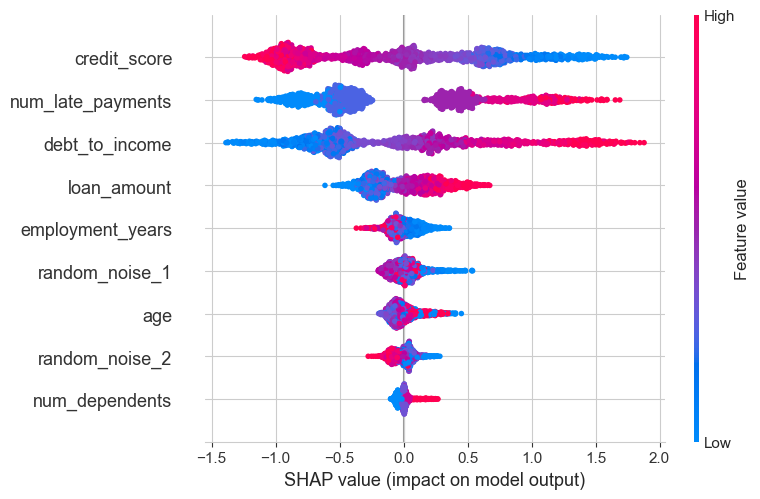

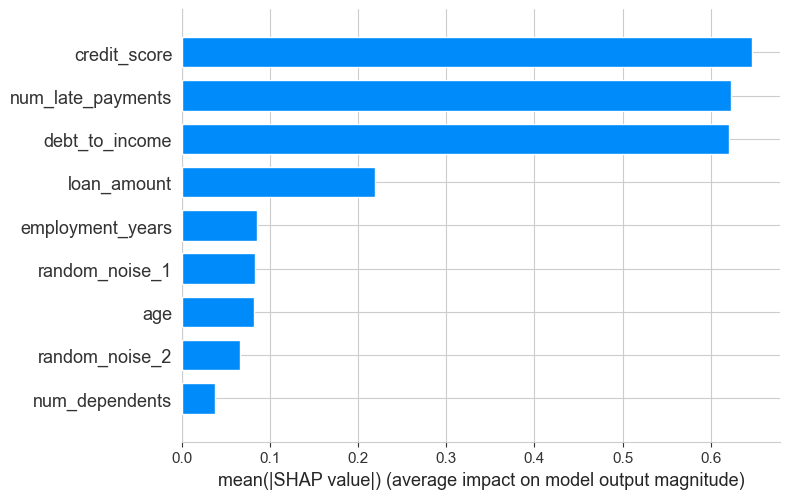

In [10]:
# TODO: постройте beeswarm plot
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# TODO: постройте bar plot (агрегированная важность)
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar')


**Ваш ответ:** Как видно по графику тёплых пчёлок самые влияющие на предсказание признаки это credit_score, num_late_payments, debt_to_income. Они лежат в большом диапазоне значений примерно от -1.5 и до 2.0. По графику bar plot та же картина, эти 3 значения лежат в диапазоне от 0.0 до 0.6, ещё можно выделить loan_amount, у него есть значимый вклад, лежит от 0.0 до 0.2, но с большим отрывом от тех, что в топ-3. 
Шумовыми же можно назвать employment_years, random_noise_1, age, random_noise_2 и num_dependents. На графике тёплых пчел значения этих признаков лежат в узком поле, собраны по центру, примерно от -0.3 до 0.3. На втором графике bar plot этим признакам  соответствуют самые короткие столбики, лежат от примерно 0.05 до 0.09, что сильно короче, по сравнению с другими.

Список немного совпадает с ожиданиями по названиям. Шумовыми признаками оказались random_noise_1 и random_noise_2, собственно по названию уже всё было понятно, и модель действительно почти не использует их для предсказания. Интересно то, что содержательные на первый взгляд признаки, такие как age и employment_years, оказались тоже малозначимыми, как и те, что со случайным шумом. Возможно это из-за того, что их влияние на дефолт уже объяснено через credit_score, debt_to_income, num_late_payments, которые четче отражают платёжеспособность заёмщика.

### 2.2 Dependence plot — поиск попарных взаимодействий

**Задание:** постройте dependence plot для 2-3 наиболее важных признаков (по умолчанию SHAP сам подберёт цвет по признаку с наибольшим взаимодействием). Найдите признак, у которого зависимость SHAP value от значения самого признака выглядит по-разному в зависимости от цвета (значения второго признака) — это и есть взаимодействие. Дополнительно постройте dependence plot с явно заданным `interaction_index`, чтобы проверить гипотезу о конкретной паре признаков.

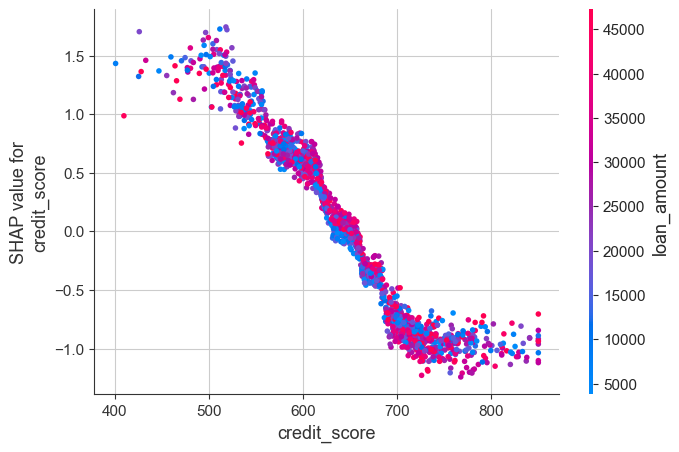

In [11]:
# TODO: постройте dependence plot для наиболее важного признака (по умолчанию)
shap.dependence_plot('credit_score', shap_values, X_test, feature_names=feature_names)

# TODO: постройте dependence plot с явно заданным interaction_index для проверки конкретной гипотезы



**Ваш ответ:** Как мы видим, библиотека выбрала loan_amount как признак с наибольшим взаимодействием с credit_score. Теперь можно построить dependence plot для проверки гипотезы.

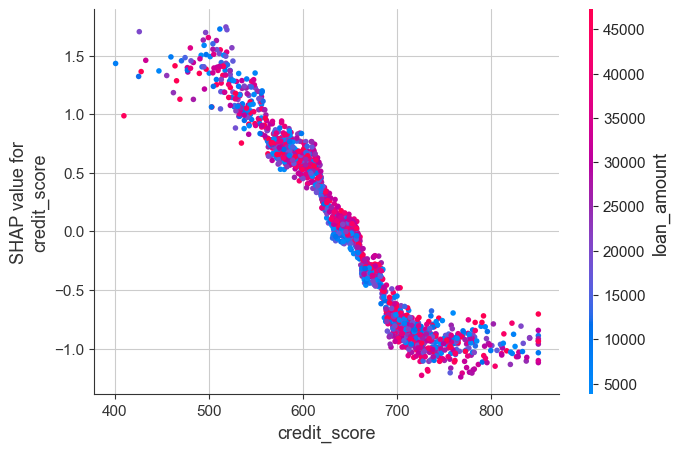

In [12]:
shap.dependence_plot('credit_score', shap_values, X_test, feature_names=feature_names, interaction_index='loan_amount')

Можно сказать, что формально loan_amount признак с наибольшим, относительно других, взаимодействием с credit_score, но абсолютная сила их взаимодействия не самая большая, так как loan_amount находится на 4-ом месте по важности. Поэтому хочу попробовать построить ещё один график взаимодействия. Хочу взять признак num_late_payments и debt_to_income, так как интуитивно высокая долговая нагрузка будет рисковеннее для тех, у кого уже были просрочки, а не у тех, кто платил вовремя.

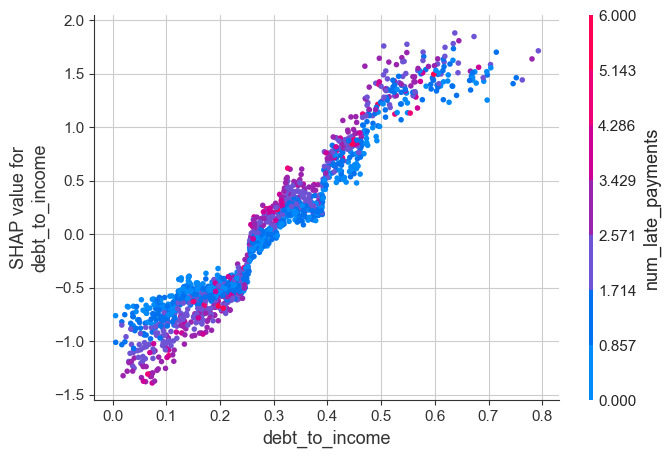

In [13]:
shap.dependence_plot('debt_to_income', shap_values, X_test, feature_names=feature_names, interaction_index='num_late_payments')

Здесь уже видим возрастающую монотонную зависимость. Для debt_to_income растёт вместе с самим значением признака, то есть при низкой долговой нагрузке примерно от 0.0 до 0.2 SHAP value на графике отрицательный, а значит риск дефолта снижается, а при высокой от 0.5 и выше, риск дефолта растёт и он сильно положительный. Гипотеза подтверждается. Высокая долговая нагрузка воспринимается моделью как более рискованная именно вместе с историей просрочек. Делаю вывод, что модель хорошо выучила нелинейную комбинацию двух этих признаков.

## 3. Итоговые выводы (3 балла)

Кратко (в виде bullet points) резюмируйте:
- Какие гиперпараметры оказались важны, а какие можно было не тюнить?
- Была ли сетка поиска гиперпараметров задана удачно?
- Какие признаки оказались шумовыми?
- Какое взаимодействие признаков вы обнаружили и согласуется ли оно с вашей интуицией о кредитном риске?

**Ваш ответ:** 
1) Важными гиперпараметрами можно назвать (для plot_param_importances) lambda_l1 (0.37), bagging_fraction (0.22), learning_rate (0.25), bagging_freq (0.09). А те, которые можно было не тюнить, а зафиксировать на дефолте: lambda_l2 (0.03), feature_fraction (0.02), num_leaves (0.04). Менее очевидными же оказались lambda_l1 и lambda_l2, они регуляризаторы с одинаковым диапазоном поиска, но их важности сильно различаются.

Сетка поиска задана неудачно для lambda_l1, так как на графике contour plot было видно, что зона максимального AUC прижата к верхней границе диапазона (10) и она обрывалась, а не образовывала оптимум внутри области поиска. Верхнюю границу можно было бы задать примерно 100. Для остальных гиперпараметров очевидного упирания в край на contour plot не было зафиксировано, хотя визуально могло так казаться.

Шумовыми признаками оказались random_noise_1, random_noise_2 и employment_years и age, и в целом num_dependents. Если первые два очевидны из-за названия в датасете, то вторые  интуитивно должны были влиять на риск сильнее. Думаю, как и писала выше, они уже объяснены через credit_score, debt_to_income, num_late_payments.

Взаимодействие признаков было обнаружено между debt_to_income и num_late_payments. Собственно высокая долговая нагрузка повышает предсказанный риск заметно сильнее у заёмщиков, у которых уже есть история просрочек, чем у тех, кто платил вовремя, при одном и том же уровне долга. С интуицией точно согласуется, так как было заметно на графике, комбинация двух признаков риска опаснее, чем каждый по отдельности. А вот взаимодействие credit_score с loan_amount (SHAP сам подобрал), на самом деле оказалось не самым сильным. Модель в основном использовала признаки независимо, без явных нелинейных комбинаций между большей частью пар.

Спасибо большое за небольшую и приятную домашку! Такое очень понравилось :)

![мем](IMG_4847.JPG) 

